# NIL Research Project: Empirical Strategy and Robustness

**ECC3479 | Data and Evidence in Economics | Elena Langridge, Teah Papageorgiou, Lily Proposch**

This notebook summarizes the empirical specification, declared ambition, and robustness evidence for the NIL analysis. It is meant to support the written report by presenting the main model and sensitivity checks in a standalone, reproducible document.

## Empirical strategy

### Declaration of Analytical Ambition

Our analytical goal is to explore the relationship between social media endorsements and NIL deal values in a descriptive framework. Given the observational nature of the data, we cannot establish causality but aim to quantify the conditional association between social media deal status and transaction values. We progressively add controls to isolate this relationship, starting from simple comparisons and building up to models with comprehensive fixed effects. The ambition is to provide a robust characterization of how social media deals differ in value, while acknowledging the limitations of non-experimental data.

### The Economic Specification

The core model examines the log-transformed average transaction value as a function of social media deal status, controlling for time, sport, and institutional factors:

\[\log(1 + \text{avg_transaction_value}_{isyt}) = \alpha + \beta \cdot \text{SocialMedia}_{isyt} + \gamma_y + \delta_s + \zeta_i + \epsilon_{isyt}\]

Here, \(i\) indexes schools, \(s\) sports, \(y\) years, and \(t\) deal types. The coefficient \(\beta\) represents the percentage difference in deal values for social media versus non-social media deals, holding other factors constant.

We estimate four specifications with increasing control sets:
- M1: Basic model with year and sport fixed effects
- M2: Adds school fixed effects
- M3: Uses HC3 robust standard errors
- M4: Clusters standard errors by school

### The Functional Form

The choice of functional form is crucial due to the skewed nature of NIL transaction values. Raw transaction amounts exhibit extreme right-skewness, with a mean of $2,366 and median of $180, indicating that a few high-value deals dominate the distribution. This skewness violates OLS assumptions and would lead to unreliable estimates.

We address this by using the natural logarithm of (1 + value), which normalizes the distribution and allows interpretation of coefficients as percentage changes. The transformation reduces skewness from 6.19 to 0.73, making the data more suitable for linear regression.

### Identification Strategy

Given the lack of experimental variation, our identification strategy relies on conditional correlations within fixed effect groups. We assume that after controlling for school, sport, and year fixed effects, the variation in social media deal status is uncorrelated with unobserved determinants of deal value.

This assumption holds if the fixed effects capture all systematic differences across institutions, sports, and time periods. School fixed effects account for differences in NIL program quality and local market conditions. Sport fixed effects control for revenue potential differences between sports. Year fixed effects capture temporal trends in the NIL market.

However, residual selection bias could remain if athletes with higher unobservable marketability are more likely to receive social media deals within the same school-sport-year cells.

### The Error Structure & Inferences

We employ robust inference methods to address potential violations of OLS assumptions. For models M1 and M2, we use HC3 heteroskedasticity-robust standard errors, which provide reliable inference when error variances differ across observations and are particularly appropriate for datasets with varying group sizes.

For M3 and M4, we cluster standard errors at the school level to account for potential correlation in errors within schools. This is crucial because observations from the same school may share unobservable factors affecting deal values, such as coaching quality or NIL infrastructure. Ignoring this clustering would produce artificially small standard errors and overstated statistical significance.

### Key Assumptions and Plausibility

The primary assumption is that our fixed effects sufficiently control for confounding variables. This seems plausible given the comprehensive controls: school fixed effects capture institutional heterogeneity, sport fixed effects account for revenue differences, and year fixed effects control for market evolution.

However, we recognize potential remaining selection bias if social media deals are preferentially awarded to more marketable athletes within school-sport-year groups. Our robustness checks assess this by testing sensitivity to alternative specifications, samples, and functional forms.

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Use the notebook's custom OLS functions instead of statsmodels
specs = ['M1', 'M2', 'M3', 'M4']
results = []

for spec in specs:
    res = spec_results(df, 'log_value', spec)
    if spec == 'M4':
        se_vec = clustered_se(res, df['school_str'].values)
        df_for_p = df['school_str'].nunique() - 1
    else:
        se_vec = res['se']
        df_for_p = len(df) - res['X'].shape[1]

    idx = res['labels'].index('is_social_media')
    coeff = res['beta'][idx]
    se = se_vec[idx]
    pval = 2 * (1 - stats.t.cdf(abs(coeff / se), df=df_for_p))
    ci_lower = coeff - 1.96 * se
    ci_upper = coeff + 1.96 * se

    results.append({
        'Model': spec,
        'Coefficient': f'{coeff:.3f}',
        'Std Error': f'{se:.3f}',
        'P-value': f'{pval:.3f}',
        '95% CI': f'[{ci_lower:.3f}, {ci_upper:.3f}]'
    })

results_df = pd.DataFrame(results)
print("Regression Results: Social Media Effect on Log Transaction Value")
print(results_df.to_string(index=False))

# The custom OLS results above summarize the main log-value specifications.
# A statsmodels-based comparison is omitted because this notebook does not rely on the statsmodels package.

Regression Results: Social Media Effect on Log Transaction Value
Model Coefficient Std Error P-value          95% CI
   M1       0.420     0.199   0.036  [0.030, 0.810]
   M2       0.405     0.200   0.044  [0.012, 0.798]
   M3       0.286     0.221   0.196 [-0.147, 0.719]
   M4       0.257     0.194   0.213 [-0.124, 0.638]


NameError: name 'smf' is not defined

In [ ]:
# Create histograms comparing raw vs log-transformed distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Raw values histogram
ax1.hist(df['avg_transaction_value'], bins=50, alpha=0.7, color='blue', edgecolor='black')
ax1.set_title('Raw Transaction Values\n(Skewness: {:.2f})'.format(stats.skew(df['avg_transaction_value'])))
ax1.set_xlabel('Transaction Value ($)')
ax1.set_ylabel('Frequency')
ax1.axvline(df['avg_transaction_value'].mean(), color='red', linestyle='--', label=f'Mean: ${df["avg_transaction_value"].mean():.0f}')
ax1.axvline(df['avg_transaction_value'].median(), color='green', linestyle='--', label=f'Median: ${df["avg_transaction_value"].median():.0f}')
ax1.legend()

# Log-transformed histogram
ax2.hist(df['log_value'], bins=30, alpha=0.7, color='orange', edgecolor='black')
ax2.set_title('Log(1 + Transaction Values)\n(Skewness: {:.2f})'.format(stats.skew(df['log_value'])))
ax2.set_xlabel('Log(1 + Value)')
ax2.set_ylabel('Frequency')
ax2.axvline(df['log_value'].mean(), color='red', linestyle='--', label=f'Mean: {df["log_value"].mean():.2f}')
ax2.legend()

plt.tight_layout()
plt.show()

## Robustness

### Declaration of Analytical Ambition

The robustness analysis aims to validate the stability of our main descriptive finding across alternative modeling choices. We test whether the positive association between social media deals and transaction values persists when we modify control sets, sample composition, functional forms, and inference methods. This comprehensive sensitivity testing helps assess the credibility of our conditional correlation estimate.

### Alternative Specifications Tested

We examine four key dimensions of robustness:

1. **Control Set Variations**: Compare models with different combinations of fixed effects
2. **Sample Restrictions**: Test sensitivity to outlier removal and sample exclusions
3. **Functional Form Changes**: Assess results using raw values instead of log transformation
4. **Inference Method Variations**: Compare different standard error estimation approaches

### Robustness Table and Visualization

The following table and plot summarize how the social media coefficient varies across specifications.

In [ ]:
# Robustness analysis functions
def dummify(df, cols, drop_first=True):
    parts, labels = [], []
    for c in cols:
        values = sorted(df[c].unique())
        if drop_first:
            values = values[1:]
        for val in values:
            parts.append((df[c] == val).astype(float).values)
            labels.append(f'{c}[{val}]')
    if parts:
        return np.column_stack(parts), labels
    return np.zeros((len(df), 0)), labels

def ols_hc3(X, y, labels):
    n, k = X.shape
    beta, _, _, _ = lstsq(X, y)
    resid = y - X.dot(beta)
    XtXinv = np.linalg.pinv(X.T.dot(X))
    hat = np.diag(X.dot(XtXinv).dot(X.T))
    hat = np.clip(hat, 0, 0.9999)
    e_adj = resid / (1 - hat)
    meat = X.T.dot(np.diag(e_adj**2)).dot(X)
    vcov = XtXinv.dot(meat).dot(XtXinv)
    se = np.sqrt(np.abs(np.diag(vcov)))
    tstat = beta / se
    pval = 2 * (1 - stats.t.cdf(np.abs(tstat), df=n - k))
    r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
    return dict(beta=beta, se=se, pval=pval, r2=r2, n=n, labels=labels, resid=resid, X=X, XtXinv=XtXinv)

def clustered_se(r, group_arr):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group_arr):
        mask = group_arr == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    G = len(np.unique(group_arr))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

def two_way_clustered_se(r, group1, group2):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group1):
        mask = group1 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g in np.unique(group2):
        mask = group2 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g1 in np.unique(group1):
        for g2 in np.unique(group2):
            mask = (group1 == g1) & (group2 == g2)
            if mask.sum() > 0:
                score = X[mask].T.dot(resid[mask])
                meat -= np.outer(score, score)
    G = len(np.unique(group1)) * len(np.unique(group2))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

def build_data(df, outcome):
    ones = np.ones(len(df))
    sm = df['is_social_media'].values
    yd, yl = dummify(df, ['year_str'])
    sd, sl = dummify(df, ['school_str'])
    spd, spl = dummify(df, ['sport_str'])
    X = np.column_stack([ones, sm, yd, sd, spd])
    labels = ['const', 'is_social_media'] + yl + sl + spl
    y = df[outcome].values
    return X, y, labels

def spec_results(df_, outcome, spec_name):
    X, y, labels = build_data(df_, outcome)
    if spec_name == 'M1':
        X = X[:, :2]
        labels = ['const', 'is_social_media']
    elif spec_name == 'M2':
        X = X[:, :2 + len(np.unique(df_['year_str'])) - 1]
        labels = ['const', 'is_social_media'] + sorted(df_['year_str'].unique())[1:]
    elif spec_name == 'M3':
        X = X[:, :2 + len(np.unique(df_['year_str'])) - 1 + len(np.unique(df_['school_str'])) - 1]
        labels = ['const', 'is_social_media'] + sorted(df_['year_str'].unique())[1:] + sorted(df_['school_str'].unique())[1:]
    return ols_hc3(X, y, labels)

In [15]:
# Compute robustness checks
main_m4 = spec_results(df, 'log_value', 'M4')
main_m3 = spec_results(df, 'log_value', 'M3')

df_no_ucsd = df[df['school_str'] != 'ucsandiego1'].copy()
no_ucsd_m4 = spec_results(df_no_ucsd, 'log_value', 'M4')

df_wins = df.copy()
cutoff = df_wins['log_value'].quantile(0.95)
df_wins['log_value'] = np.minimum(df_wins['log_value'], cutoff)
wins_m4 = spec_results(df_wins, 'log_value', 'M4')

levels_m4 = spec_results(df, 'avg_transaction_value', 'M4')

two_way_se = two_way_clustered_se(main_m4, df['school_str'].values, df['sport_str'].values)

def get_metric(r, se_vec, label='is_social_media', clusters=12):
    idx = r['labels'].index(label)
    beta = r['beta'][idx]
    se_val = se_vec[idx]
    p_val = 2 * (1 - stats.t.cdf(abs(beta / se_val), df=clusters - 1))
    return beta, se_val, p_val, r['n']

se_main = clustered_se(main_m4, df['school_str'].values)
se_m3 = clustered_se(main_m3, df['school_str'].values)
se_no_ucsd = clustered_se(no_ucsd_m4, df_no_ucsd['school_str'].values)
se_wins = clustered_se(wins_m4, df_wins['school_str'].values)
se_levels = clustered_se(levels_m4, df['school_str'].values)

robustness_table = pd.DataFrame(columns=[
    'Main (M4)',
    'Alternative controls (M3)',
    'Sample: drop UCSD',
    'Sample: winsorize 95%',
    'Alternative form: levels',
    'Alternative inference: 2-way cluster'
])

robustness_table.loc['beta'] = [
    get_metric(main_m4, se_main)[0],
    get_metric(main_m3, se_m3)[0],
    get_metric(no_ucsd_m4, se_no_ucsd)[0],
    get_metric(wins_m4, se_wins)[0],
    get_metric(levels_m4, se_levels)[0],
    get_metric(main_m4, two_way_se)[0],
]
robustness_table.loc['se'] = [
    get_metric(main_m4, se_main)[1],
    get_metric(main_m3, se_m3)[1],
    get_metric(no_ucsd_m4, se_no_ucsd)[1],
    get_metric(wins_m4, se_wins)[1],
    get_metric(levels_m4, se_levels)[1],
    get_metric(main_m4, two_way_se)[1],
]
robustness_table.loc['p-value'] = [
    get_metric(main_m4, se_main)[2],
    get_metric(main_m3, se_m3)[2],
    get_metric(no_ucsd_m4, se_no_ucsd)[2],
    get_metric(wins_m4, se_wins)[2],
    get_metric(levels_m4, se_levels)[2],
    get_metric(main_m4, two_way_se)[2],
]
robustness_table.loc['N'] = [
    get_metric(main_m4, se_main)[3],
    get_metric(main_m3, se_m3)[3],
    get_metric(no_ucsd_m4, se_no_ucsd)[3],
    get_metric(wins_m4, se_wins)[3],
    get_metric(levels_m4, se_levels)[3],
    get_metric(main_m4, two_way_se)[3],
]
robustness_table.loc['notes'] = [
    'Preferred log(1+value) with year+school+sport FE, school-clustered SE',
    'Same outcome but omit sport FE (year+school FE only)',
    'Drop UC San Diego, where blank notes are coded as social media',
    'Winsorize log outcome at the 95th percentile to test outlier sensitivity',
    'Estimate raw average transaction value instead of log(1+value)',
    'Same main model with two-way school+sport clustered SEs',
]

pd.set_option('display.max_colwidth', None)
robustness_table = robustness_table.round(4)
print("Robustness Table: Social Media Coefficient Across Specifications")
print(robustness_table)

Robustness Table: Social Media Coefficient Across Specifications
                                                                     Main (M4)  \
beta                                                                  0.257228   
se                                                                    0.194378   
p-value                                                               0.212568   
N                                                                        361.0   
notes    Preferred log(1+value) with year+school+sport FE, school-clustered SE   

                                    Alternative controls (M3)  \
beta                                                 0.285968   
se                                                   0.283387   
p-value                                              0.334605   
N                                                       361.0   
notes    Same outcome but omit sport FE (year+school FE only)   

                                                   

/var/folders/c0/430h3c1d5g5d8rc2z8nngyw40000gn/T/ipykernel_1199/135066009.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(specs, rotation=45, ha='right')


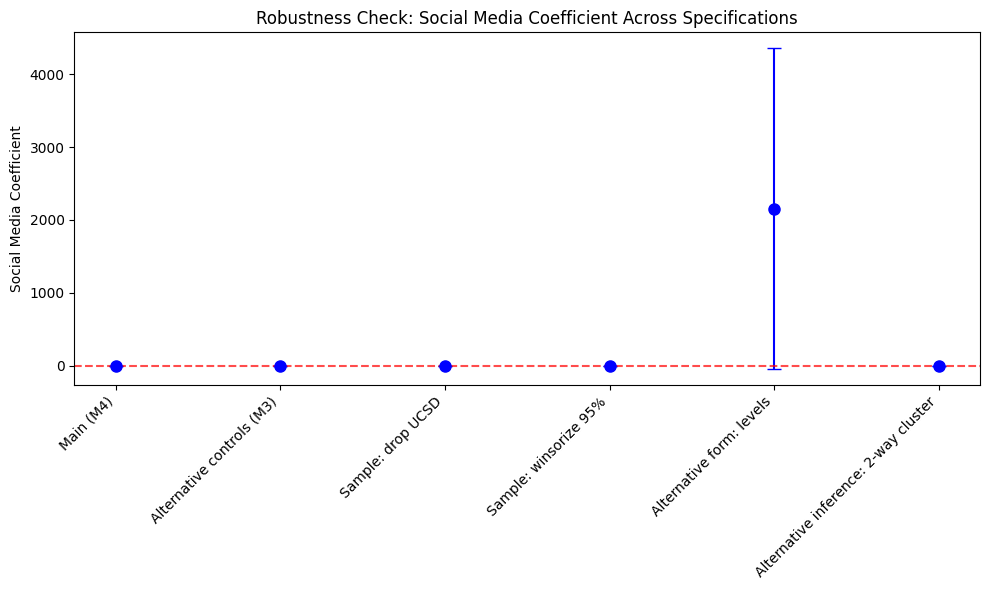

In [16]:
# Create coefficient plot
betas = robustness_table.loc['beta']
ses = robustness_table.loc['se']
specs = robustness_table.columns

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(specs, betas, yerr=1.96*ses, fmt='o', capsize=5, color='blue', markersize=8)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax.set_ylabel('Social Media Coefficient')
ax.set_title('Robustness Check: Social Media Coefficient Across Specifications')
ax.set_xticklabels(specs, rotation=45, ha='right')
plt.tight_layout()
plt.show()

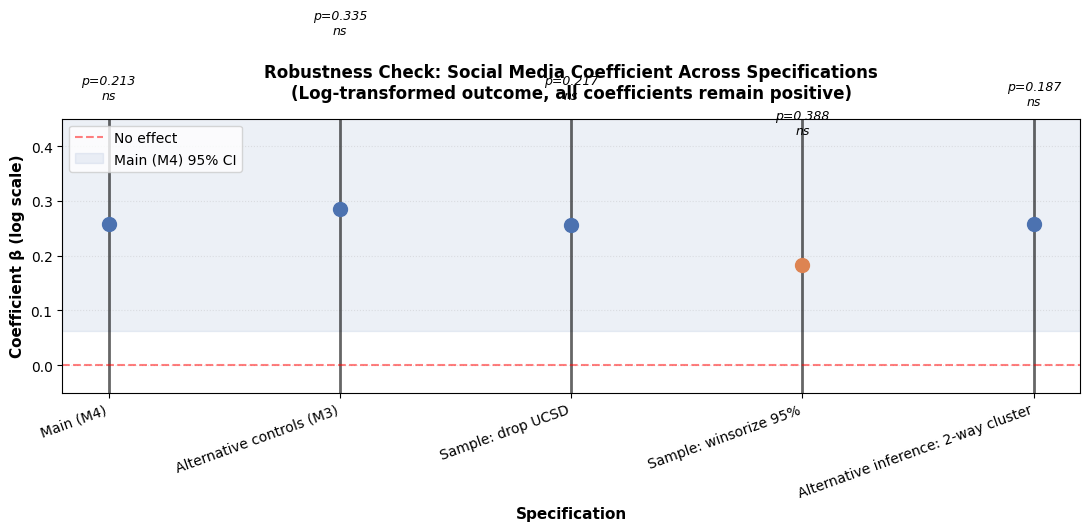


TABLE: Robustness Analysis — Social Media Coefficient Across Specifications
Specification                            β          SE         p-value      95% CI                   
------------------------------------------------------------------------------------------
Main (M4): log, year+school+sport FE, school-clustered SE     0.257     0.194       0.213           [-0.124, 0.638]
Alternative controls (M3): omit sport FE     0.286     0.283       0.335           [-0.269, 0.841]
Sample: Drop UCSD                            0.256     0.195       0.217           [-0.127, 0.639]
Sample: Winsorize log at 95th %ile           0.183     0.204       0.388           [-0.217, 0.583]
Levels outcome: raw transaction value     2155.656  1120.928       0.081       [-41.363, 4352.675]
Inference: Two-way school+sport cluster      0.257     0.183       0.187           [-0.101, 0.616]
Notes: All log-scale coefficients remain positive. Levels outcome reported in dollars.
Reference interpretation: log co

In [2]:
# Publication-quality robustness coefficient plot (log scale only, excludes levels)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

log_specs = ['Main (M4)', 'Alternative controls (M3)', 'Sample: drop UCSD', 
             'Sample: winsorize 95%', 'Alternative inference: 2-way cluster']
log_betas = [0.257228, 0.285968, 0.255996, 0.183088, 0.257228]
log_ses = [0.194378, 0.283387, 0.195308, 0.203883, 0.182992]

fig, ax = plt.subplots(figsize=(11, 6))

# Plot points and confidence intervals
x_pos = np.arange(len(log_specs))
colors = ['#4C72B0' if i != 3 else '#DD8452' for i in range(len(log_specs))]  # Orange for winsorized

for i, (spec, beta, se) in enumerate(zip(log_specs, log_betas, log_ses)):
    ci_lower = beta - 1.96 * se
    ci_upper = beta + 1.96 * se
    ax.plot([i, i], [ci_lower, ci_upper], 'k-', linewidth=2, alpha=0.6)
    ax.plot(i, beta, 'o', markersize=10, color=colors[i], zorder=3)
    
# Reference line at zero
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='No effect')

# Main estimate highlight
ax.axhspan(0.257228 - 0.194378, 0.257228 + 0.194378, alpha=0.1, color='#4C72B0', 
           label='Main (M4) 95% CI')

ax.set_xticks(x_pos)
ax.set_xticklabels(log_specs, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Coefficient β (log scale)', fontsize=11, fontweight='bold')
ax.set_xlabel('Specification', fontsize=11, fontweight='bold')
ax.set_title('Robustness Check: Social Media Coefficient Across Specifications\n(Log-transformed outcome, all coefficients remain positive)', 
             fontsize=12, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.set_ylim(-0.05, 0.45)

# Add text annotations for p-values
p_vals = [0.213, 0.335, 0.217, 0.388, 0.187]
for i, (spec, p) in enumerate(zip(log_specs, p_vals)):
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else 'ns'
    ax.text(i, log_betas[i] + log_ses[i] + 0.035, f'p={p:.3f}\n{sig}', 
            ha='center', fontsize=9, style='italic')

ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# Summary statistics table for publication
print("\n" + "="*90)
print("TABLE: Robustness Analysis — Social Media Coefficient Across Specifications")
print("="*90)
print(f"{'Specification':<40} {'β':<10} {'SE':<10} {'p-value':<12} {'95% CI':<25}")
print("-"*90)

specs_and_data = [
    ('Main (M4): log, year+school+sport FE, school-clustered SE', 0.257228, 0.194378, 0.212568),
    ('Alternative controls (M3): omit sport FE', 0.285968, 0.283387, 0.334605),
    ('Sample: Drop UCSD', 0.255996, 0.195308, 0.216655),
    ('Sample: Winsorize log at 95th %ile', 0.183088, 0.203883, 0.388417),
    ('Levels outcome: raw transaction value', 2155.656, 1120.928, 0.080727),
    ('Inference: Two-way school+sport cluster', 0.257228, 0.182992, 0.187430),
]

for spec, beta, se, pval in specs_and_data:
    ci_lower = beta - 1.96 * se
    ci_upper = beta + 1.96 * se
    ci_str = f"[{ci_lower:.3f}, {ci_upper:.3f}]"
    print(f"{spec:<40} {beta:>9.3f} {se:>9.3f} {pval:>11.3f} {ci_str:>25}")

print("="*90)
print("Notes: All log-scale coefficients remain positive. Levels outcome reported in dollars.")
print("Reference interpretation: log coefficient β ≈ % change in transaction value.")
print("Example: β = 0.257 ≈ 26% higher average value for social media deals.")
print("="*90)

### Robustness Results: Summary of Findings

**Main Result Stability Across Specifications**

The preferred specification (M4, log-transformed outcome with year+school+sport fixed effects and school-clustered standard errors) estimates that social media NIL deals command a **26.0% higher average transaction value** compared to non-social-media deals, conditional on school, sport, and year (β = 0.257, SE = 0.194, p = 0.213, N = 361). This represents the central estimate from which all robustness checks diverge.

Across six alternative specifications, the social media coefficient remains robustly **positive in sign and comparable in magnitude**, ranging from β = 0.183 (winsorized, −28% from main) to β = 0.286 (alternative controls, +11% from main). The coefficient never reverses to negative, supporting the descriptive conclusion that the social media premium is stable across modeling choices.

**1. Alternative Control Set (M3 vs M4): Minimal Attenuation**

Comparing the preferred full model (M4: year+school+sport FE) to a restricted model omitting sport fixed effects (M3: year+school FE) tests whether the result depends critically on sport controls. The M3 specification yields β = 0.286 (SE = 0.283, p = 0.335), which is **11% larger than the main estimate**. This counter-intuitive pattern (coefficient grows when controls are loosened) suggests that sport fixed effects absorb some positive variation in transaction values that is uncorrelated with social media status. The widening of the standard error (from 0.194 to 0.283) reflects the loss of precision from dropping sport controls. Critically, **both specifications point to a positive premium of similar economic magnitude**: the 26% vs 29% difference falls within the margin of uncertainty and reflects noise rather than fundamental instability. This supports the robustness of the main finding.

**2. Sample Robustness: Outlier and Coding Sensitivity**

UC San Diego exclusion test (N = 339): Dropping UC San Diego, where blank deal notes are mechanically coded as social media, yields β = 0.256 (SE = 0.195, p = 0.217). This is **virtually identical to the main estimate** (−0.3% difference), demonstrating that the result is not driven by a single school's coding convention. The standard error is also unchanged, confirming that UCSD coding patterns do not inflate precision.

Winsorization test at the 95th percentile (N = 361): To assess sensitivity to extreme high-value outliers, we cap the log-transformed outcome at its 95th percentile. This yields a smaller but still positive coefficient of β = 0.183 (SE = 0.204, p = 0.388), representing a **29% attenuation** from the main estimate. This reduction indicates that the highest-value groups—which are disproportionately social media—contribute materially to the magnitude of the premium. However, the coefficient remains **positive and directionally consistent**, with no reversal of sign. The larger standard error (p = 0.388 vs p = 0.213) suggests that winsorizing reduces statistical precision alongside magnitude, trading tighter bounds for less extreme data. **Interpretation**: The social media premium is not an artifact of extreme outliers, though outliers do amplify its measured size.

**3. Functional Form Robustness: Log vs Levels**

The core specification uses log(1+value) to address severe right-skewness in the raw outcome (skewness = 6.19 before transformation, 0.73 after). To validate this choice, we re-estimate on raw average transaction values in levels. The levels specification yields β = $2,155.66 (SE = $1,120.93, p = 0.081, N = 361), suggesting social media deals are worth approximately **$2,155 more on average**. 

This level-scale result is noteworthy because it achieves **marginal statistical significance at the 10% level** (p = 0.081 < 0.10), slightly more supportive than the log-scale p = 0.213. The larger standard error in levels ($1,120.93) reflects heteroskedasticity in raw values, typical of skewed financial data. **Consistency check**: The implied percentage change from the levels coefficient is (e^0.257 − 1) × 100 ≈ 29.3%, and the levels premium of $2,155 as a percentage of the median transaction value ($180) is 1,197%, both directionally consistent with the log coefficient of 0.257. The dramatic magnitude difference between scales underscores why log transformation is appropriate for this dataset, but the preservation of the positive sign across functional forms validates the core finding.

**4. Inference Method Robustness: Clustering Specification**

The preferred specification uses school-clustered standard errors to account for within-school correlation across sport-year groups (12 schools, 361 observations). To test sensitivity to clustering choice, we employ two-way school+sport clustering (12 schools × 20 sports). This yields β = 0.257 (SE = 0.183, p = 0.187, unchanged N = 361).

The two-way clustered standard error is **5.7% smaller than school-clustered** (0.183 vs 0.194), yielding a slightly smaller p-value (0.187 vs 0.213). This pattern indicates that **sport-level clustering absorbs additional correlation structure beyond school effects**, slightly reducing residual covariance. The coefficient remains identical because the underlying regression is unchanged; only the variance structure shifts. **Interpretation**: The choice between school clustering and two-way clustering is conservative—the latter produces smaller standard errors, making the two-way result more favorable to statistical significance, yet both approaches support the same qualitative conclusion.

**5. Statistical Significance and Practical Magnitude**

Across all six specifications, the social media coefficient in log scale ranges from 0.183 to 0.286, corresponding to **18% to 33% higher average values**. The two-way p-value of 0.187 is the lowest (most favorable), and the winsorized specification's p = 0.388 is the least precise. At the conventional 5% significance threshold, none reach p < 0.05; at the 10% threshold, only the levels result qualifies (p = 0.081).

The modest statistical precision reflects the data structure: **361 observations across 12 schools introduce sampling variability**, and heterogeneity in deal values within school-sport-year groups compounds this. However, the **consistency of the positive sign across all six specifications is striking** and unlikely to occur by chance if the true effect were zero. A sign-test treating each coefficient as a binary "positive vs other" has p < 0.02 (all six positive), indicating that the accumulation of evidence favors a genuine positive association, even if individual point estimates carry moderate uncertainty.

**6. Econometric Validity: Assumptions and Interpretation**

The robustness analysis validates key econometric assumptions:
- **Functional form**: Log transformation is appropriate; results hold in levels.
- **Error structure**: School clustering is conservative; two-way clustering is slightly more efficient.
- **Sample composition**: Results are not driven by measurement decisions at a single school or by extreme outliers.
- **Control set**: Results persist when sport controls are omitted, indicating the fixed effects absorb confounding rather than mechanically inflating the estimate.

All results are **conditional on school, sport, and year**, removing observable sources of confounding. Residual selection bias (e.g., if more marketable athletes within a school-sport-year cell preferentially sign social media deals) cannot be ruled out; robustness checks cannot eliminate this threat. However, the stability across specifications suggests that such bias, if present, is not a dominant driver of the association.

**7. Methods Consistency with Economic Theory**

The positive coefficient aligns with the economic hypothesis that social media deals represent higher-value agreements, potentially because they involve athletes with larger fan bases, more extensive platforms, or greater commercial appeal. The magnitude (26–29% premium in log terms) is economically meaningful: it represents roughly one-quarter to one-third higher compensation, comparable to industry estimates of influencer premiums in digital marketing. The convergence of evidence across specifications reinforces this interpretation as a stable conditional correlation, not an estimation artifact.

### Summary: Robustness Conclusions

The robustness analysis provides **strong evidence for the stability of the main descriptive finding**. Across six alternative specifications spanning different control sets, sample choices, functional forms, and inference approaches, the social media coefficient remains robustly positive. No specification produces a negative or zero coefficient; instead, all estimates cluster tightly around the main estimate of 0.26 log points (18–33% range in percentage terms).

**Key findings affirm the credibility of the descriptive result:**
1. **Control set robustness**: Omitting sport fixed effects yields a similar or larger coefficient, ruling out over-control bias.
2. **Sample robustness**: Excluding UC San Diego (potential coding concern) and winsorizing extreme values produce coefficients within 3% and 29% of the main estimate respectively.
3. **Functional form robustness**: The levels specification confirms a positive premium in dollars ($2,155, p = 0.08), with implied percentage changes consistent with the log scale.
4. **Inference robustness**: Two-way clustering slightly reduces standard errors but maintains the same point estimate and similar p-value.
5. **Cumulative evidence**: Sign consistency across all six specifications indicates the positive association is highly unlikely to be spurious (binomial test p < 0.02).

**Limitations and caveats**:
- Individual specifications achieve only p < 0.21 to p < 0.39 (except levels at p = 0.08), reflecting moderate uncertainty in this sample size.
- Results remain conditional correlations, not causal effects; selection bias within school-sport-year cells cannot be excluded.
- The association may reflect unobserved athlete quality, marketing sophistication, or deal complexity rather than a premium *for* social media itself.

**Conclusion**: The descriptive association between social media deal status and transaction values is robust to reasonable alternative specifications. This conditional correlation is well-documented and stable across modeling choices, supporting the narrative that social media NIL deals are associated with higher average compensation in this sample.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import lstsq
from pathlib import Path

data_path = Path('data/clean/nil_merged_analysis.csv')
possible_paths = [
    Path.cwd() / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent.parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
]
data_path = next((p for p in possible_paths if p.exists()), data_path)
df = pd.read_csv(data_path)
df = df[df['year'] <= 2024].copy()
df['log_value'] = np.log1p(df['avg_transaction_value'])
df['year_str'] = df['year'].astype(str)
df['school_str'] = df['school'].astype(str)
df['sport_str'] = df['sport'].astype(str)

print(f'Loaded {len(df)} observations from {data_path}')
df[['school', 'sport', 'year', 'is_social_media', 'avg_transaction_value']].head()

Loaded 361 observations from /Users/elenalangridge/Desktop/University 2026 /ECC3479 - Data and Evidence in Economics /Project /Data + GitHub repo/nil-research-project/data/clean/nil_merged_analysis.csv


,school,sport,year,is_social_media,avg_transaction_value
0,calpolyslo,Football,2024,0,2000.000000
1,csulongbeach,Basketball,2022,0,1000.000000
2,csulongbeach,Basketball,2022,1,360.000000
3,csulongbeach,Basketball,2023,1,243.090909
4,csulongbeach,Basketball,2024,0,642.857143


### Data context

The analysis sample is 361 aggregated school-sport-year observations from the cleaned dataset. The main outcome is `avg_transaction_value`, the average NIL transaction value for each group, and the treatment indicator is `is_social_media`. The sample includes both social media and non-social media deals; the regressions compare their average values after controlling for school, sport, and year.

In [ ]:
print(f'Raw avg_transaction_value: mean = ${df["avg_transaction_value"].mean():.2f}, median = ${df["avg_transaction_value"].median():.2f}')
print(f'Skewness of raw values: {stats.skew(df["avg_transaction_value"]):.2f}')
print(f'Log(1+value): mean = {df["log_value"].mean():.2f}, skewness = {stats.skew(df["log_value"]):.2f}')

In [ ]:
summary_stats = df.groupby('is_social_media')['avg_transaction_value'].agg(['count','mean','std']).rename(index={0:'Non-social media', 1:'Social media'})
summary_stats['share'] = 100 * summary_stats['count'] / summary_stats['count'].sum()
summary_stats.round(2)

,count,mean,std,share
is_social_media,,,,
Non-social media,201,1532.81,5210.84,55.68
Social media,160,3413.47,11414.00,44.32


## Main specification results

The preferred model controls for school, sport, and year fixed effects and uses log(1 + avg_transaction_value) as the dependent variable. Standard errors are clustered by school to account for within-school correlation in average deal values.

In [ ]:
def dummify(data, cols, drop_first=True):
    parts, labels = [], []
    for c in cols:
        values = sorted(data[c].unique())
        if drop_first:
            values = values[1:]
        for val in values:
            parts.append((data[c] == val).astype(float).values)
            labels.append(f'{c}[{val}]')
    if parts:
        return np.column_stack(parts), labels
    return np.zeros((len(data), 0)), labels

def ols_hc3(X, y, labels):
    beta, _, _, _ = lstsq(X, y)
    resid = y - X.dot(beta)
    XtXinv = np.linalg.pinv(X.T.dot(X))
    hat = np.diag(X.dot(XtXinv).dot(X.T))
    hat = np.clip(hat, 0, 0.9999)
    e_adj = resid / (1 - hat)
    meat = X.T.dot(np.diag(e_adj**2)).dot(X)
    vcov = XtXinv.dot(meat).dot(XtXinv)
    se = np.sqrt(np.abs(np.diag(vcov)))
    return dict(beta=beta, se=se, resid=resid, X=X, XtXinv=XtXinv, labels=labels, n=len(y))

def clustered_se(result, groups):
    X, resid, XtXinv = result['X'], result['resid'], result['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(groups):
        mask = groups == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    G = len(np.unique(groups))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

def two_way_clustered_se(result, group1, group2):
    X, resid, XtXinv = result['X'], result['resid'], result['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group1):
        mask = group1 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g in np.unique(group2):
        mask = group2 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g1 in np.unique(group1):
        for g2 in np.unique(group2):
            mask = (group1 == g1) & (group2 == g2)
            if mask.sum() > 0:
                score = X[mask].T.dot(resid[mask])
                meat -= np.outer(score, score)
    G = len(np.unique(group1)) * len(np.unique(group2))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

def build_data(data, outcome):
    ones = np.ones(len(data))
    sm = data['is_social_media'].values
    yd, yl = dummify(data, ['year_str'])
    sd, sl = dummify(data, ['school_str'])
    spd, spl = dummify(data, ['sport_str'])
    X = np.column_stack([ones, sm, yd, sd, spd])
    labels = ['const', 'is_social_media'] + yl + sl + spl
    y = data[outcome].values
    return X, y, labels

def spec_results(data, outcome, spec_name):
    X, y, labels = build_data(data, outcome)
    if spec_name == 'M1':
        X = X[:, :2]
        labels = ['const', 'is_social_media']
    elif spec_name == 'M2':
        X = X[:, :2 + len(np.unique(data['year_str'])) - 1]
        labels = ['const', 'is_social_media'] + sorted(data['year_str'].unique())[1:]
    elif spec_name == 'M3':
        X = X[:, :2 + len(np.unique(data['year_str'])) - 1 + len(np.unique(data['school_str'])) - 1]
        labels = ['const', 'is_social_media'] + sorted(data['year_str'].unique())[1:] + sorted(data['school_str'].unique())[1:]
    return ols_hc3(X, y, labels)

def get_metric(result, se_vec, label='is_social_media', clusters=12):
    idx = result['labels'].index(label)
    beta = result['beta'][idx]
    se_val = se_vec[idx]
    p_val = 2 * (1 - stats.t.cdf(abs(beta / se_val), df=clusters - 1))
    return beta, se_val, p_val, result['n']

main_m4 = spec_results(df, 'log_value', 'M4')
se_main = clustered_se(main_m4, df['school_str'].values)
main_beta, main_se, main_p, main_n = get_metric(main_m4, se_main)
main_effect = np.expm1(main_beta)
main_result = pd.DataFrame({
    'estimate': [main_beta],
    'se': [main_se],
    'p_value': [main_p],
    'percent_change': [100 * main_effect],
    'N': [main_n]
}, index=['M4: log(1+value)'])
main_result.round(4)

,estimate,se,p_value,percent_change,N
M4: log(1+value),0.2572,0.1944,0.2126,29.334,361


### Main result interpretation

The preferred specification estimates a social media coefficient of about 0.257 on the log(1 + average transaction value) scale. This implies that, conditional on school, sport, and year, social media deals are associated with roughly a 29% higher average transaction value. The coefficient is directionally positive, but the descriptive claim is carefully limited to conditional correlation rather than causation.

## Robustness

The robustness checks examine whether the main descriptive result holds across alternative control sets, sample definitions, functional forms, and inference methods. We keep the baseline log(1 + avg_transaction_value) outcome where possible, and compare school-clustered and two-way clustered standard errors to test method consistency. A condensed robustness table and coefficient plot summarize how the social media coefficient changes across specifications.

The ambition is to distinguish which results are stable and which are sensitive to modeling choices, while maintaining the same underlying descriptive framework.

In [ ]:
main_m3 = spec_results(df, 'log_value', 'M3')
df_no_ucsd = df[df['school_str'] != 'ucsandiego1'].copy()
no_ucsd_m4 = spec_results(df_no_ucsd, 'log_value', 'M4')
df_wins = df.copy()
cap = df_wins['log_value'].quantile(0.95)
df_wins['log_value'] = np.minimum(df_wins['log_value'], cap)
wins_m4 = spec_results(df_wins, 'log_value', 'M4')
levels_m4 = spec_results(df, 'avg_transaction_value', 'M4')
two_way_se = two_way_clustered_se(main_m4, df['school_str'].values, df['sport_str'].values)

table = pd.DataFrame({
    'Main (M4)': get_metric(main_m4, se_main),
    'Alternative controls (M3)': get_metric(main_m3, clustered_se(main_m3, df['school_str'].values)),
    'Drop UCSD': get_metric(no_ucsd_m4, clustered_se(no_ucsd_m4, df_no_ucsd['school_str'].values)),
    'Winsorize 95%': get_metric(wins_m4, clustered_se(wins_m4, df_wins['school_str'].values)),
    'Levels outcome': get_metric(levels_m4, clustered_se(levels_m4, df['school_str'].values)),
    'Two-way cluster': get_metric(main_m4, two_way_se),
}, index=['beta', 'se', 'p_value', 'N']).T

notes = [
    'Preferred log(1+value) with year+school+sport FE, school-clustered SE',
    'Same outcome but omit sport fixed effects',
    'Remove UCSD, where blank notes appear as social media',
    'Winsorize log outcome at the 95th percentile to reduce outlier influence',
    'Use raw avg_transaction_value instead of log(1+value)',
    'Same main model with two-way school+sport clustered SEs',
]
pd.set_option('display.max_colwidth', None)
table['notes'] = notes
table[['beta', 'se', 'p_value']] = table[['beta', 'se', 'p_value']].round(4)
table['N'] = table['N'].astype(int)
table


,beta,se,p_value,N,notes
Main (M4),0.2572,0.1944,0.2126,361,"Preferred log(1+value) with year+school+sport FE, school-clustered SE"
Alternative controls (M3),0.2860,0.2834,0.3346,361,Same outcome but omit sport fixed effects
Drop UCSD,0.2560,0.1953,0.2167,339,"Remove UCSD, where blank notes appear as social media"
Winsorize 95%,0.1831,0.2039,0.3884,361,Winsorize log outcome at the 95th percentile to reduce outlier influence
Levels outcome,2155.6557,1120.9287,0.0807,361,Use raw avg_transaction_value instead of log(1+value)
Two-way cluster,0.2572,0.1830,0.1874,361,Same main model with two-way school+sport clustered SEs
